In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/1
    print("準備完了！このまま下のセルを実行できます。")

# 1.3 モデル選択 & 1.4 次元の呪い (Model Selection and Curse of Dimensionality)

本ノートブックでは、機械学習の実践において最も重要となる2つの根本的課題を学びます：
1. **1.3 モデル選択 (Model Selection)**：
   - 過学習を回避し、未知データに対する汎化性能を最大化するためのモデル複雑さ（ハイパーパラメータ）の選択
   - ホールドアウト検証、**S分割交差検証 (S-Fold Cross-Validation)**（PRML Figure 1.18）
   - **情報量基準 (AIC, BIC)** によるモデル複雑さのペナルティ評価
2. **1.4 次元の呪い (Curse of Dimensionality)**：
   - 入力変数の次元数 $D$ が増大した際に生じる直観に反する幾何学的・統計的現象
   - **超球の体積の表面近傍への集中**（PRML Figure 1.22）
   - **多変量ガウス分布における確率質量の球殻への集中**（PRML Figure 1.23）
   - **高次元距離の集中現象**（最近傍と最遠傍の無差別化）と次元削減・多様体仮説の必然性

## 1.3 モデル選択 (Model Selection)

多項式フィッティングにおける次数 $M$ や、正則化パラメータ $\ln\lambda$ のようなハイパーパラメータを決定する際、訓練データ上の二乗和誤差を指標にすると過学習（Overfitting）を招きます。

### 交差検証法 (Cross-Validation)
データを $S$ 個のグループ（Fold）に均等に分割し、$S-1$ 個をモデルの学習に、残り1個を評価に用いる試行を $S$ 回繰り返します（PRML Figure 1.18）。
各Foldでの検証誤差の平均値を交差検証誤差（CV Error）とし、これを最小化するモデルを選択します。

### 情報量基準 (Information Criteria)
クロスバリデーションが計算コストを要するのに対し、訓練データのみを用いて過学習ペナルティを課す指標として以下があります：
- **AIC (Akaike Information Criterion)**:
$$
\mathrm{AIC} = 2k - 2\ln L = 2k + N \ln(\mathrm{MSE}) + \mathrm{const}
$$
- **BIC (Bayesian Information Criterion)**:
$$
\mathrm{BIC} = k \ln N - 2\ln L = k \ln N + N \ln(\mathrm{MSE}) + \mathrm{const}
$$
ここで $k$ は自由パラメータ数（多項式次数 $M$ の場合 $k = M+1$）、$N$ はサンプル数、$L$ は最大尤度です。

5-Fold CV 最適次数 M: 3
AIC 最適次数 M:       3
BIC 最適次数 M:       3
Plot saved to: result/fig1_model_selection_cv_aic.png


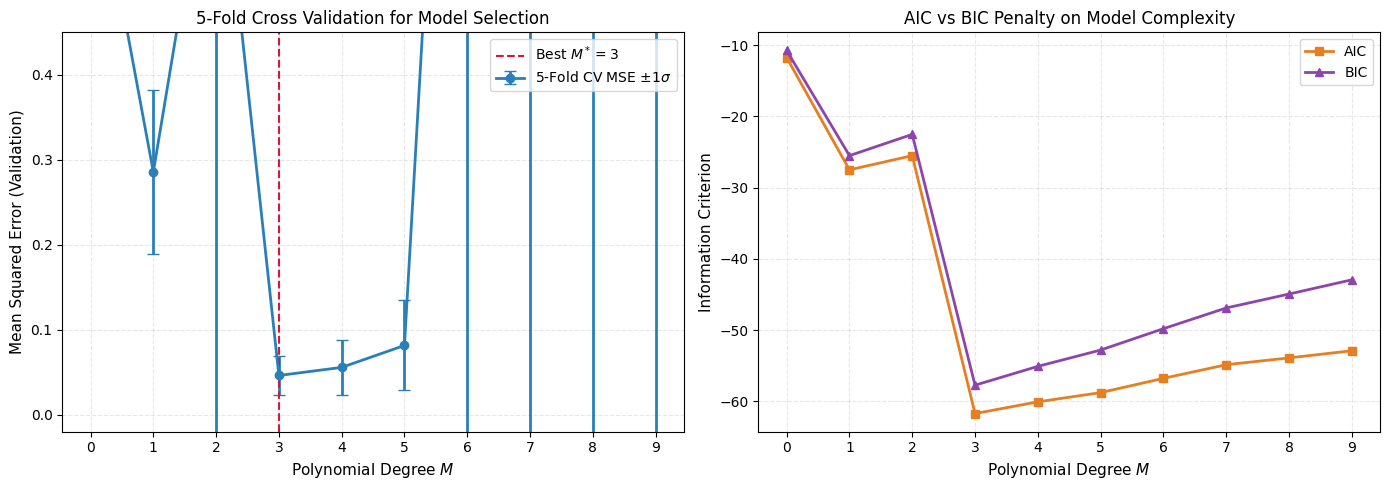

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
setup_style()

np.random.seed(42)

# データ生成
def true_fn(x):
    return np.sin(2 * np.pi * x)

N = 20
x_data = np.sort(np.random.uniform(0, 1, N))
t_data = true_fn(x_data) + np.random.normal(0, 0.2, N)

def poly_features(x, degree):
    return np.vstack([x**i for i in range(degree + 1)]).T

# 5分割交差検証 (S=5 Fold Cross Validation)
S = 5
indices = np.arange(N)
np.random.shuffle(indices)
folds = np.array_split(indices, S)

degrees = np.arange(0, 10)
cv_scores = np.zeros((S, len(degrees)))
aic_scores = np.zeros(len(degrees))
bic_scores = np.zeros(len(degrees))

# 全データでのフィッティングと AIC/BIC
for j, deg in enumerate(degrees):
    Phi_all = poly_features(x_data, deg)
    w_all = np.linalg.pinv(Phi_all) @ t_data
    mse_all = np.mean((t_data - Phi_all @ w_all)**2)
    k = deg + 1
    aic_scores[j] = 2 * k + N * np.log(mse_all + 1e-10)
    bic_scores[j] = k * np.log(N) + N * np.log(mse_all + 1e-10)

# CVループ
for s in range(S):
    val_idx = folds[s]
    train_idx = np.setdiff1d(indices, val_idx)
    
    x_tr, t_tr = x_data[train_idx], t_data[train_idx]
    x_va, t_va = x_data[val_idx], t_data[val_idx]
    
    for j, deg in enumerate(degrees):
        Phi_tr = poly_features(x_tr, deg)
        w = np.linalg.pinv(Phi_tr) @ t_tr
        
        Phi_va = poly_features(x_va, deg)
        pred_va = Phi_va @ w
        cv_scores[s, j] = np.mean((t_va - pred_va)**2)

mean_cv = np.mean(cv_scores, axis=0)
std_cv = np.std(cv_scores, axis=0)

# 最適モデル
best_deg_cv = degrees[np.argmin(mean_cv)]
best_deg_aic = degrees[np.argmin(aic_scores)]
best_deg_bic = degrees[np.argmin(bic_scores)]

print(f"5-Fold CV 最適次数 M: {best_deg_cv}")
print(f"AIC 最適次数 M:       {best_deg_aic}")
print(f"BIC 最適次数 M:       {best_deg_bic}")

# プロット作成
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# パネル 1: S-Fold Cross-Validation スコア
ax1 = axes[0]
ax1.errorbar(degrees, mean_cv, yerr=std_cv, fmt='o-', color='#2980b9', lw=2, capsize=4, label='5-Fold CV MSE $\\pm 1\\sigma$')
ax1.axvline(best_deg_cv, color='crimson', linestyle='--', label=f'Best $M^* = {best_deg_cv}$')
ax1.set_xlabel('Polynomial Degree $M$', fontsize=11)
ax1.set_ylabel('Mean Squared Error (Validation)', fontsize=11)
ax1.set_title('5-Fold Cross Validation for Model Selection', fontsize=12)
ax1.set_xticks(degrees)
ax1.set_ylim(-0.02, 0.45)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.3)

# パネル 2: AIC と BIC の比較
ax2 = axes[1]
ax2.plot(degrees, aic_scores, 's-', color='#e67e22', lw=2, label='AIC')
ax2.plot(degrees, bic_scores, '^-', color='#8e44ad', lw=2, label='BIC')
ax2.set_xlabel('Polynomial Degree $M$', fontsize=11)
ax2.set_ylabel('Information Criterion', fontsize=11)
ax2.set_title('AIC vs BIC Penalty on Model Complexity', fontsize=12)
ax2.set_xticks(degrees)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_model_selection_cv_aic.png')
plt.show()

## 1.4 次元の呪い (Curse of Dimensionality)

機械学習において、入力変数の次元数 $D$ が増大すると、低次元（2次元や3次元）での幾何学的直観が完全に破綻します。これを**次元の呪い (Curse of Dimensionality)** と呼びます。

### 1. 超球の体積の表面への集中（PRML Figure 1.22）
半径 $r$ の $D$ 次元球の体積は、ある定数 $S_D$ を用いて以下のように表されます：
$$
V_D(r) = C_D r^D
$$
半径 $1$ の球において、外側の境界から厚さ $\epsilon$ （すなわち内側半径 $1-\epsilon$ から $1$ まで）の球殻（shell）に含まれる体積の割合は：
$$
\frac{V_D(1) - V_D(1 - \epsilon)}{V_D(1)} = \frac{1^D - (1 - \epsilon)^D}{1^D} = 1 - (1 - \epsilon)^D
$$
$D$ が大きくなると、たとえ $\epsilon$ が非常に小さくても、この割合は急速に $1$ に近づきます！
すなわち、**高次元の球体において、ほぼすべての体積はごく薄い表面の皮（殻）に集中**します。

### 2. 多変量ガウス分布における確率質量の球殻への集中（PRML Figure 1.23）
$D$ 次元等方性ガウス分布 $p(\mathbf{x}) = (2\pi\sigma^2)^{-D/2} \exp(-\|\mathbf{x}\|^2 / 2\sigma^2)$ を極座標変換し、原点からの距離 $r = \|\mathbf{x}\|$ の動径確率密度 $p(r)$ を求めると：
$$
p(r) = S_D r^{D-1} (2\pi\sigma^2)^{-D/2} \exp\left(-\frac{r^2}{2\sigma^2}\right)
$$
ここで $S_D r^{D-1}$ は半径 $r$ の $D$ 次元超球の表面積です。
原点 $r=0$ では確率密度自体は最大値をとりますが、**体積要素 $r^{D-1}$ が原点近傍でゼロに潰れるため、確率質量が集中する半径は原点から離れた球殻となります**。
動径密度の最頻値（ピーク）は、$\frac{d}{dr}\ln p(r) = 0$ を解くことで得られます：
$$
\frac{D-1}{r} - \frac{r}{\sigma^2} = 0 \implies r_{\max} = \sigma \sqrt{D-1}
$$
高次元では、ガウス分布のサンプルは原点付近ではなく、半径 $\sigma\sqrt{D}$ の**薄い球殻（Thin Shell）上に偏在**します！

Plot saved to: result/fig1_curse_of_dimensionality_complete.png


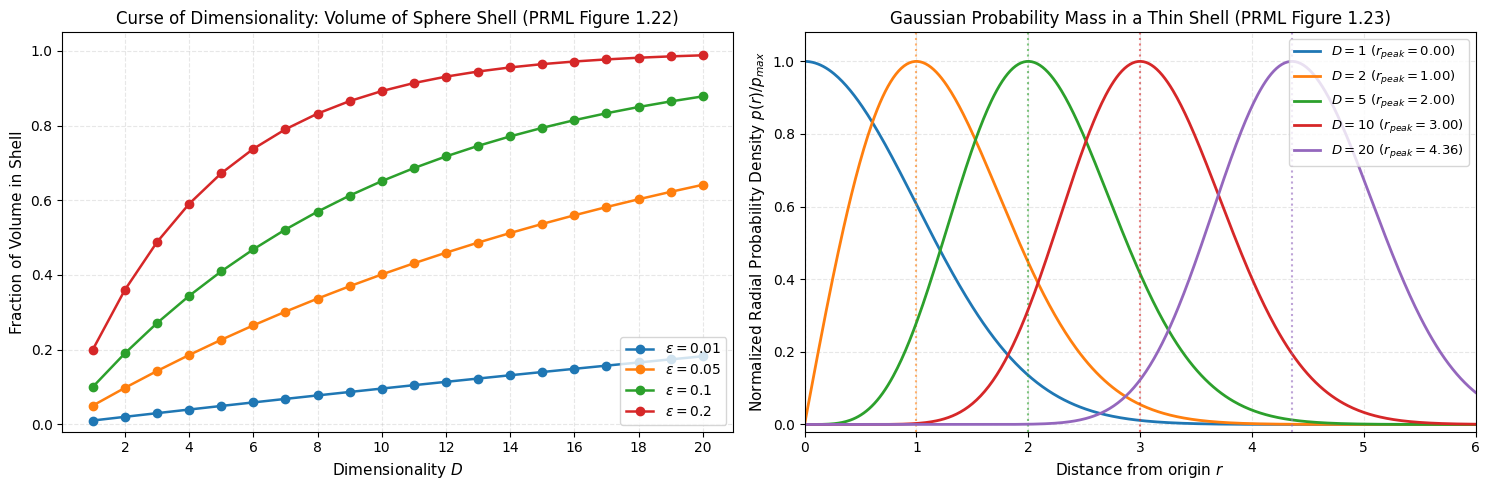

In [2]:
# PRML Figure 1.22 & Figure 1.23 の再現
from scipy.special import gamma

# パネル 1: 超球の表面への体積集中 (PRML Figure 1.22)
D_range = np.arange(1, 21)
epsilons = [0.01, 0.05, 0.1, 0.2]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
for eps in epsilons:
    fraction = 1 - (1 - eps)**D_range
    ax1.plot(D_range, fraction, 'o-', lw=1.8, label=f'$\\epsilon = {eps}$')

ax1.set_xlabel('Dimensionality $D$', fontsize=11)
ax1.set_ylabel('Fraction of Volume in Shell', fontsize=11)
ax1.set_title('Curse of Dimensionality: Volume of Sphere Shell (PRML Figure 1.22)', fontsize=12)
ax1.set_xticks(np.arange(2, 21, 2))
ax1.set_ylim(-0.02, 1.05)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.3)

# パネル 2: ガウス分布の確率質量の球殻集中 (PRML Figure 1.23)
ax2 = axes[1]
sigma = 1.0
r = np.linspace(0, 6, 500)
dims = [1, 2, 5, 10, 20]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for D, col in zip(dims, colors):
    # S_D: D次元球の表面積
    S_D = 2 * (np.pi**(D / 2.0)) / gamma(D / 2.0)
    # 動径確率密度 p(r)
    p_r = S_D * (r**(D - 1)) * ((2 * np.pi * sigma**2)**(-D / 2.0)) * np.exp(-0.5 * (r**2) / (sigma**2))
    
    # ピークの正規化表示
    p_r_norm = p_r / np.max(p_r) if np.max(p_r) > 0 else p_r
    r_peak = sigma * np.sqrt(max(0, D - 1))
    
    ax2.plot(r, p_r_norm, lw=2.0, color=col, label=f'$D = {D}$ ($r_{{peak}}={r_peak:.2f}$)')
    ax2.axvline(r_peak, color=col, linestyle=':', alpha=0.6)

ax2.set_xlabel('Distance from origin $r$', fontsize=11)
ax2.set_ylabel('Normalized Radial Probability Density $p(r) / p_{max}$', fontsize=11)
ax2.set_title('Gaussian Probability Mass in a Thin Shell (PRML Figure 1.23)', fontsize=12)
ax2.set_xlim(0, 6)
ax2.set_ylim(-0.02, 1.08)
ax2.legend(loc='upper right', fontsize=9.5)
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig1_curse_of_dimensionality_complete.png')
plt.show()

### 3. 高次元における距離の集中現象 (Distance Concentration)

高次元空間におけるもう一つの直観に反する性質は、**あらゆるペア間のユークリッド距離がほぼ等しくなる（距離の集中）** という現象です。

$D$ 次元単位超立方体 $[0, 1]^D$ から一様にランダムサンプリングされた点群において、任意の基準点から「最も近い点までの距離 $d_{\min}$」と「最も遠い点までの距離 $d_{\max}$」の相対差を調べます：
$$
\lim_{D \to \infty} \frac{d_{\max} - d_{\min}}{d_{\min}} = 0
$$
この極限は、**高次元では「近傍」と「遠方」の区別が消失する**ことを意味します。
これが、単純な k-最近傍法（k-NN）やカーネル法が高次元空間においてそのままでは機能しなくなる統計的理由です。

Plot saved to: result/fig1_distance_concentration.png


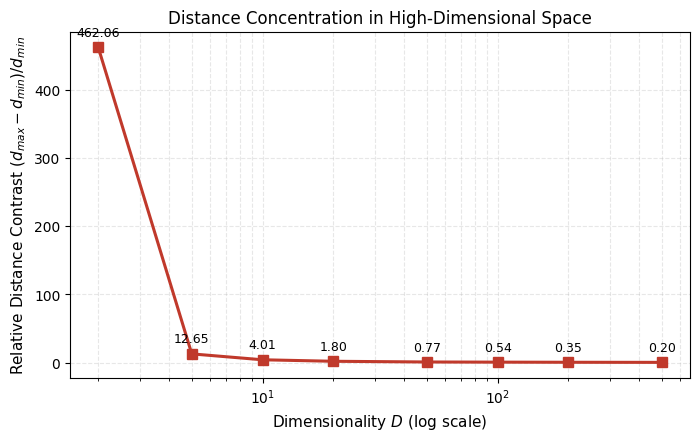

In [3]:
# 高次元における距離の集中シミュレーション
np.random.seed(42)

D_values = [2, 5, 10, 20, 50, 100, 200, 500]
N_pts = 100

relative_diffs = []

for D in D_values:
    # [0, 1]^D の一様分布から N_pts 個の点を生成
    X = np.random.uniform(0, 1, size=(N_pts, D))
    # 全ペア間距離
    from scipy.spatial.distance import pdist
    dists = pdist(X, metric='euclidean')
    d_min = np.min(dists)
    d_max = np.max(dists)
    rel_diff = (d_max - d_min) / d_min
    relative_diffs.append(rel_diff)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(D_values, relative_diffs, 's-', color='#c0392b', lw=2.2, markersize=7)
ax.set_xscale('log')
ax.set_xlabel('Dimensionality $D$ (log scale)', fontsize=11)
ax.set_ylabel('Relative Distance Contrast $(d_{max} - d_{min}) / d_{min}$', fontsize=11)
ax.set_title('Distance Concentration in High-Dimensional Space', fontsize=12)
ax.grid(True, which='both', linestyle='--', alpha=0.3)

for d, rd in zip(D_values, relative_diffs):
    ax.annotate(f'{rd:.2f}', (d, rd), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)

save_plot(fig, 'result', 'fig1_distance_concentration.png')
plt.show()

## まとめ

本節で学んだ最重要概念：
1. **モデル選択**: 訓練誤差最小化は過学習をもたらす。交差検証（S-Fold CV）や情報量基準（AIC/BIC）による汎化性能の適正評価が不可欠。
2. **球殻への体積集中**: 高次元球の体積のほぼ $100\%$ は表面近傍の薄い殻に偏在する。
3. **ガウス分布の動径密度ピーク**: $D$ 次元正規分布のサンプルは原点ではなく半径 $\sigma\sqrt{D-1}$ の球殻に集中する。
4. **距離の集中**: 高次元では $(d_{\max} - d_{\min})/d_{\min} \to 0$ となり、最近傍法などの局所的推論が困難化する。
5. **打開策**: 実世界のデータは高次元空間の全体に一様に分布しているのではなく、本質的に低次元の**多様体（Manifold）** の近傍に集中しているという仮説を利用することで、PRMLの以降の章（PCA, カーネル法, ニューラルネットワーク）で高次元データを克服していきます。